## Practice with Facebook Prophet

###  Installation in Python

In [2]:
# %pip install prophet

Let’s import the modules that we will need, and initialize our environment:

In [3]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np 
import pandas as pd
import statsmodels.api as sm
from scipy import stats

import matplotlib.pyplot as plt
#%config InlineBackend.figure_format = 'retina'

### Dataset

In [4]:
def get_file(filename, out_path:Path, overwrite=False):
    file_exists = (out_path/filename).exists()

    if file_exists:
        print("file exists")
    else:
        print("file not found")

    

In [5]:
FILE_NAME = "medium_posts.csv"
DATA_PATH =  Path(".")

get_file(filename=FILE_NAME, out_path=DATA_PATH)

file exists


In [6]:
df = pd.read_csv(DATA_PATH / FILE_NAME)
df.head()

,published,domain,url
0,2012-08-13 22:54:53.510Z,medium.com,https://medium.com/policy/medium-terms-of-serv...
1,2012-08-13 22:57:17.248Z,medium.com,https://medium.com/policy/medium-privacy-polic...
2,2016-11-04 23:40:43.364Z,medium.com,https://medium.com/@Medium/personalize-your-me...
3,2016-12-24 18:21:13.427Z,medium.com,https://medium.com/holiday-poems/xmas-morning-...
4,2015-09-22 21:37:48.207Z,blog.medium.com,https://blog.medium.com/taking-a-side-on-net-n...


Next, we leave out all columns except published and url. The former corresponds to the time dimension while the latter uniquely identifies a post by its URL. Along the way we get rid of possible duplicates and missing values in the data:

In [7]:
df = df[["published", "url"]].dropna().drop_duplicates()

Next, we need to convert published to the datetime format because by default pandas treats this field as string-valued.

In [8]:
df["published"] = pd.to_datetime(df["published"])

In [9]:
df.sort_values(by=["published"]).head(n=2)

,published,url
50931,1970-01-01 00:00:00.001000+00:00,https://medium.com/iiot
40243,1970-01-01 00:00:00.001000+00:00,https://medium.com/@ikaella/melon-rebranding-b...


Medium’s public release date was August 15, 2012. But, as you can see from the data above, there are at least several rows with much earlier publication dates. They have somehow turned up in our dataset, but they are hardly legitimate ones. We will just trim our time series to keep only those rows that fall onto the period from August 15, 2012 to June 25, 2017:

In [10]:
df = df[(df["published"] > "2012-08-15") & (df["published"] < "2017-06-26")].sort_values(by=["published"])
df.head(n=3)

,published,url
24630,2012-08-15 00:25:03.373000+00:00,https://medium.com/launch-day/jean-attempts-to...
24631,2012-08-15 00:25:29.419000+00:00,https://medium.com/launch-day/dan-and-kristin-...
17811,2012-08-15 00:34:59.502000+00:00,https://medium.com/i-m-h-o/the-world-is-social...


In [11]:
df.tail(n=3)

,published,url
62122,2017-06-25 23:36:01.171000+00:00,https://medium.com/push-the-pace/the-official-...
72471,2017-06-25 23:41:48.295000+00:00,https://medium.com/parti-xyz-developers/%EA%B4...
83283,2017-06-25 23:51:43+00:00,http://www.johanr.com/blog/people-support-dreams


In [12]:
aggr_df = df.groupby("published")[["url"]].count()
aggr_df.columns = ["posts"]

In this practice, we are interested in the number of posts a day. But at this moment all our data is divided into irregular time intervals that are less than a day. This is called a sub-daily time series. To see it, let’s print out the first 3 rows:

In [13]:
aggr_df.head(n=3)

,posts
published,
2012-08-15 00:25:03.373000+00:00,1
2012-08-15 00:25:29.419000+00:00,1
2012-08-15 00:34:59.502000+00:00,1


To fix this, we need to aggregate the post counts by “bins” of a date size. In time series analysis, this process is referred to as resampling. If we reduce the sampling rate of data, it is often called downsampling.

Luckily, pandas has a built-in functionality for this task. We will resample our time index down to 1-day bins:

In [14]:
daily_df = aggr_df.resample("D").apply(sum)
daily_df.head(n=3)

,posts
published,
2012-08-15 00:00:00+00:00,16
2012-08-16 00:00:00+00:00,11
2012-08-17 00:00:00+00:00,4


##  Exploratory visual analysis

In [15]:
from plotly import graph_objs as go
from plotly.offline import init_notebook_mode, iplot, plot
from IPython.display import display, IFrame

# initilise plotly
init_notebook_mode(connected=True)

define a helper function, which will plot our dataframes throughout the article:

```python
common_kw = dict(x=df.index, mode="lines")
```

is basically the same as:

```python
common_kw = {
    "x": df.index,
    "mode": "lines"
}
```
This is commonly used with **Plotly**.

For example, you might later write:

```python
fig.add_scatter(y=df["posts"], **common_kw)
```

The `**common_kw` means:

> "Take the things inside `common_kw` and pass them as arguments."

So this:

```python
fig.add_scatter(y=df["posts"], **common_kw)
```

is essentially like writing:

```python
fig.add_scatter(
    y=df["posts"],
    x=df.index,
    mode="lines"
)
```


In [16]:
def plotly_df(df, title="", width=800, height=500):
    """Visualize all the dataframe columns as line plots."""
    common_kw = dict(x=df.index, mode="lines")
    data = [go.Scatter(y=df[c], name=c, **common_kw) for c in df.columns]
    layout = dict(title=title)
    fig = dict(data=data, layout=layout)

    # in a Jupyter Notebook, the following should work
    iplot(fig, show_link=False)

    # in a Jupyter Book, we save a plot offline and then render it with IFrame
    # plot_path = f"./{title}.html".replace(" ", "_")
    # plot(fig, filename=plot_path, show_link=False, auto_open=False);
    # display(IFrame(plot_path, width=width, height=height))

Let’s try and plot our dataset as is:

In [17]:
plotly_df(daily_df, title="Posts on Medium(daily)")

High-frequency data can be rather difficult to analyze.
To reduce the noise, we will resample the post counts down to weekly bins.
We save our downsampled dataframe in a separate variable because further in this practice we will work only with daily series:

In [18]:
weekly_df = daily_df.resample("W").agg(sum)

Finally we plot the result

In [19]:
plotly_df(weekly_df, title="Posts on Medium (weekly)")

Now, we’re going to omit the first few years of observations, up to 2015. First, they won’t contribute much into the forecast quality in 2017. Second, these first years, having very low number of posts per day, are likely to increase noise in our predictions, as the model would be forced to fit this abnormal historical data along with more relevant and indicative data from the recent years.

In [20]:
daily_df = daily_df.loc[daily_df.index >= "2015-01-01"]
daily_df.head()

,posts
published,
2015-01-01 00:00:00+00:00,8
2015-01-02 00:00:00+00:00,11
2015-01-03 00:00:00+00:00,11
2015-01-04 00:00:00+00:00,8
2015-01-05 00:00:00+00:00,27


from visual analysis we can see that our dataset is non-stationary with a prominent growing trend. It also demonstrates weekly and yearly seasonality and a number of abnormal days in each year.

## Making a forecast

Prophet’s API is very similar to the one you can find in sklearn. First we create a model, then call the method fit, and, finally, make a forecast. The input to the method fit is a DataFrame with two columns:

- ds (datestamp) must be of type date or datetime.

- y is a numeric value we want to predict.

In [21]:
import logging
from prophet import Prophet
logging.getLogger().setLevel(logging.ERROR)

Let’s convert our dataframe to the format required by Prophet:

In [22]:
df = daily_df.reset_index()
df.columns = ["ds", "y"]
# converting timezones (issue https://github.com/facebook/prophet/issues/831)
df["ds"] = df["ds"].dt.tz_convert(None) # removes the timezone information, making the datetime timezone-naive.
df.tail()

,ds,y
902,2017-06-21,422
903,2017-06-22,441
904,2017-06-23,421
905,2017-06-24,277
906,2017-06-25,253


The authors of the library generally advise to make predictions based on at least several months, ideally, more than a year of historical data. Luckily, in our case we have more than a couple of years of data to fit the model.
To measure the quality of our forecast, we need to ***split our dataset into the historical part, which is the first and biggest slice of our data,  and the prediction part, which will be located at the end of the timeline***. We will remove the last month from the dataset in order to use it later as a prediction target:

In [23]:
prediction_size = 30
train_df = df[:-prediction_size] # start from the beginning and stop 30 rows before the end
train_df.tail(n=3)

,ds,y
874,2017-05-24,375
875,2017-05-25,298
876,2017-05-26,269


Now we need to create a new Prophet object. Here we can pass the parameters of the model into the constructor. But in this article we will use the defaults. Then we train our model by invoking its fit method on our training dataset:

In [24]:
m = Prophet()
m.fit(train_df)

11:49:40 - cmdstanpy - INFO - Chain [1] start processing
11:49:42 - cmdstanpy - INFO - Chain [1] done processing


Using the helper method Prophet.make_future_dataframe, we create a dataframe which will contain all dates from the history and also extend into the future for those 30 days that we left out before.

In [25]:
future = m.make_future_dataframe(periods=prediction_size)
future.tail(n=3)

,ds
904,2017-06-23
905,2017-06-24
906,2017-06-25


We predict values with Prophet by passing in the dates for which we want to create a forecast. If we also supply the historical dates (as in our case), then in addition to the prediction we will get an in-sample fit for the history. Let’s call the model’s predict method with our future dataframe as an input:

In [26]:
forecast = m.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
902,2017-06-21,274.892000,267.561937,314.770956,274.592493,275.211040,15.756367,15.756367,15.756367,17.133307,17.133307,17.133307,-1.376940,-1.376940,-1.376940,0.0,0.0,0.0,290.648367
903,2017-06-22,275.593799,260.323752,311.749721,275.275245,275.934716,11.881680,11.881680,11.881680,13.073150,13.073150,13.073150,-1.191471,-1.191471,-1.191471,0.0,0.0,0.0,287.475478
904,2017-06-23,276.295597,253.398124,302.004793,275.945885,276.651044,2.479477,2.479477,2.479477,3.477335,3.477335,3.477335,-0.997858,-0.997858,-0.997858,0.0,0.0,0.0,278.775074
905,2017-06-24,276.997396,216.084113,266.860918,276.621253,277.382632,-34.826828,-34.826828,-34.826828,-34.026283,-34.026283,-34.026283,-0.800545,-0.800545,-0.800545,0.0,0.0,0.0,242.170568
906,2017-06-25,277.699195,222.473905,271.776643,277.292918,278.101643,-31.186080,-31.186080,-31.186080,-30.582179,-30.582179,-30.582179,-0.603901,-0.603901,-0.603901,0.0,0.0,0.0,246.513115


In the resulting dataframe you can see many columns characterizing the prediction, including trend and seasonality components as well as their confidence intervals. The forecast itself is stored in the yhat column.

The Prophet library has its own built-in tools for visualization that enable us to quickly evaluate the result.

First, there is a method called Prophet.plot that plots all the points from the forecast:

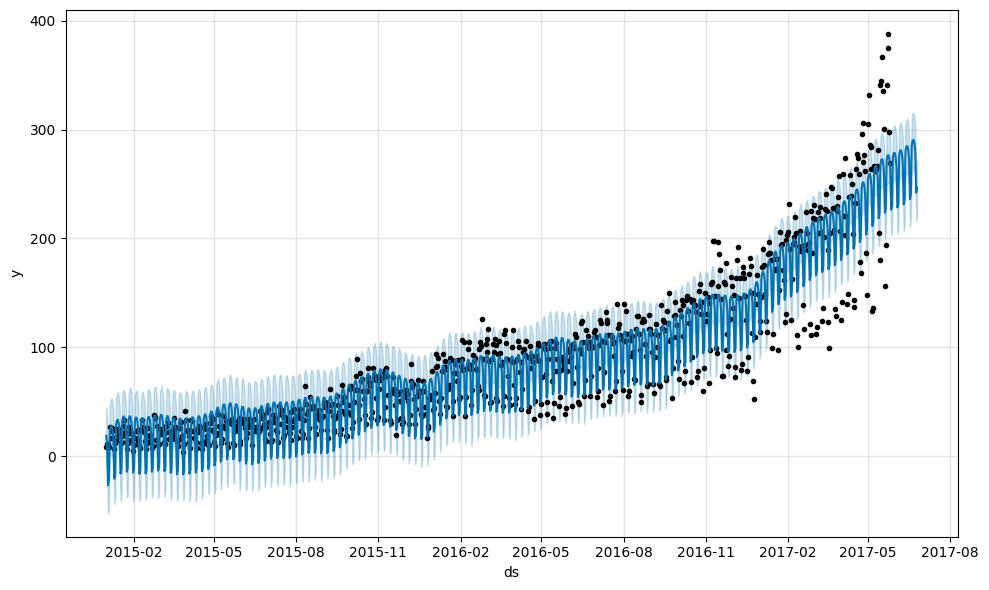

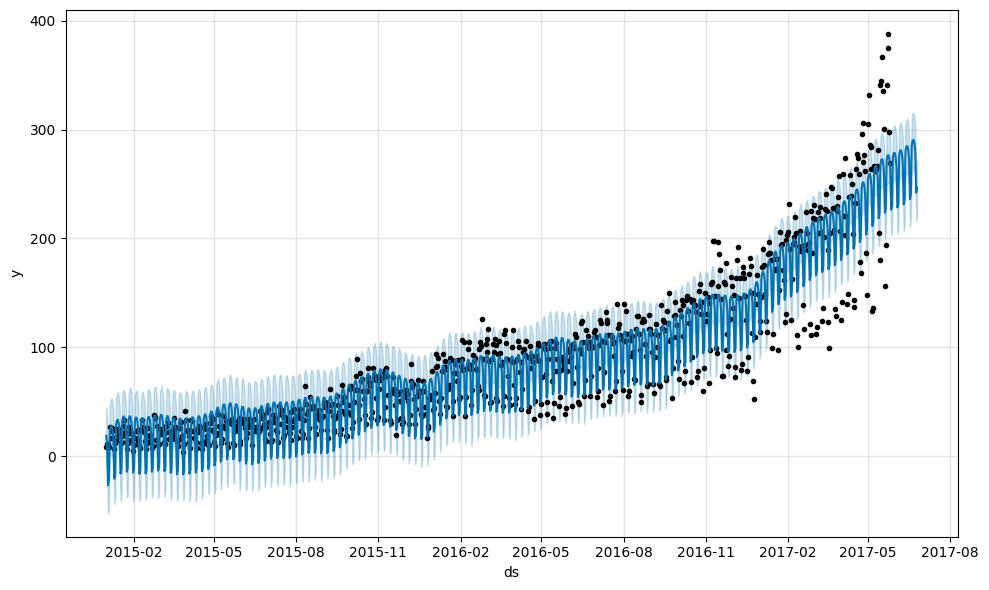

In [27]:
m.plot(forecast)

This chart doesn’t look very informative. The only definitive conclusion that we can draw here is that the model treated many of the data points as outliers.

The second function Prophet.plot_components might be much more useful in our case. It allows us to observe different components of the model separately: trend, yearly and weekly seasonality. In addition, if you supply information about holidays and events to your model, they will also be shown in this plot.

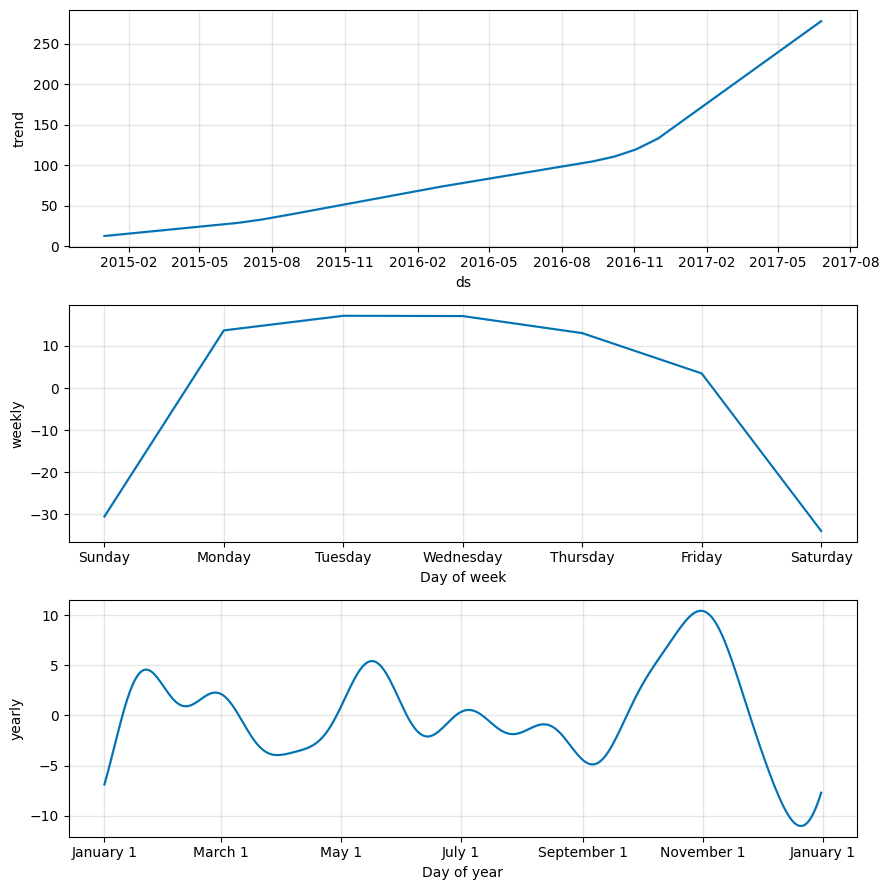

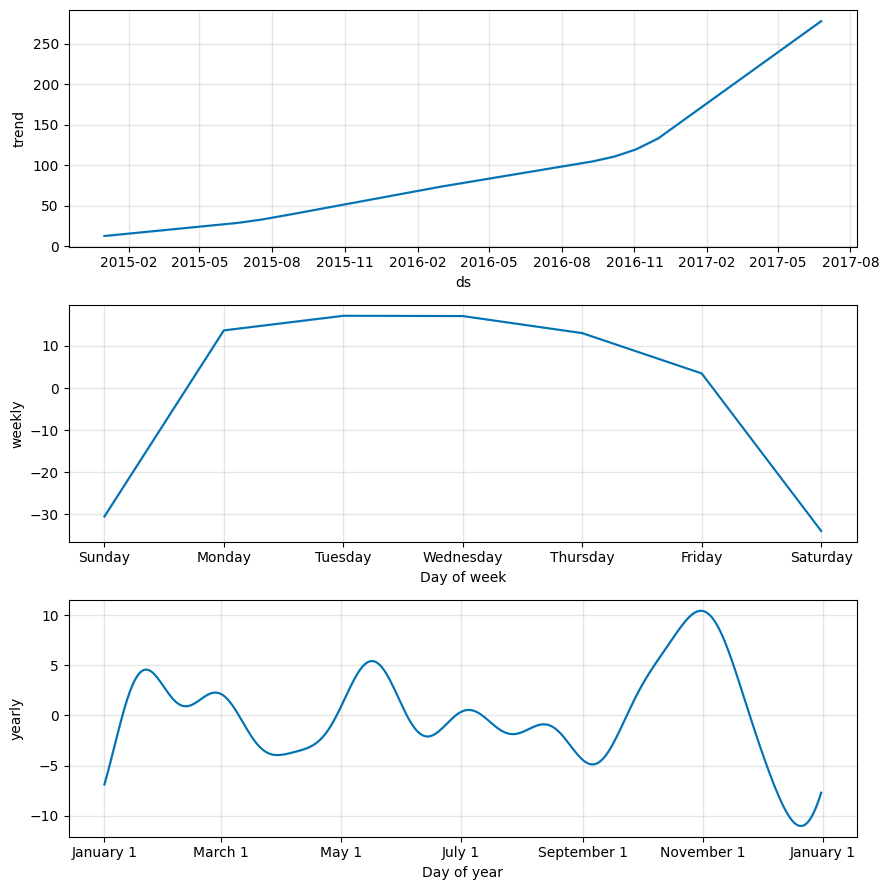

In [28]:
m.plot_components(forecast)

As you can see from the trend graph, Prophet did a good job by fitting the accelerated growth of new posts at the end of 2016. The graph of weekly seasonality leads to the conclusion that usually there are fewer new posts on Saturdays and Sundays than on the other days of the week. In the yearly seasonality graph there is a prominent dip on Christmas Day.

##  Forecast quality evaluation

Let’s evaluate the quality of the algorithm by calculating the error metrics for the last 30 days that we predicted.

Let’s look into the object forecast that the library created for us:

In [29]:
print(",".join(forecast.columns))

ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat


We can see that this dataframe contains all the information we need except for the historical values. We need to join the forecast object with the actual values y from the original dataset df.

In [30]:
def make_comparison_dataframe(historical, forecast):
    return forecast.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]].join(
        historical.set_index("ds")
    )

In [31]:
cmp_df = make_comparison_dataframe(df, forecast)
cmp_df.tail(n=3)

,yhat,yhat_lower,yhat_upper,y
ds,,,,
2017-06-23,278.775074,253.398124,302.004793,421
2017-06-24,242.170568,216.084113,266.860918,277
2017-06-25,246.513115,222.473905,271.776643,253


We are also going to define a helper function that we will use to gauge the quality of our forecasting with MAPE and MAE error measures:

In [32]:
def calculate_forecast_errors(df, prediction_size):
    """Calculate MAPE and MAE of the forecast.

       Args:
           df: joined dataset with 'y' and 'yhat' columns.
           prediction_size: number of days at the end to predict.
    """
    # make a copy
    df = df.copy()

    # calculate the values of e_i and p_i according to the formula
    df["e"] = df["y"] - df["yhat"]
    df["p"] = 100 * df["e"] / df["y"]

    # cut out the data we made prediction for
    predicted_part = df[-prediction_size:]

    # define the function that averages absolute error values over the predicted part
    error_mean = lambda error_name: np.mean(np.abs(predicted_part[error_name]))

    # calculate MAPE and MAE and return the resulting dictionary of errors.
    return{
        "MAPE" : error_mean("p"),
        "MAE" : error_mean("e")
    }

In [33]:
for err_name, err_value in calculate_forecast_errors(cmp_df, prediction_size).items():
    print(err_name, err_value)

MAPE 22.703761507050462
MAE 70.34873756705007


As a result, the relative error of our forecast (MAPE) is about 22.6%, and on average our model is wrong by ~70 posts (MAE).

##  Visualization

Let’s create our own visualization of the model built by Prophet. It will comprise the actual values, forecast and confidence intervals.

First, we will plot the data for a shorter period of time to make the data points easier to distinguish. Second, we will show the model performance only for the period that we predicted, that is the last 30 days. It seems that these two measures should give us a more legible plot.

In [34]:
def show_forecast(cmp_df, num_predictions, num_values, title, width=800, height=500):
    """Visualize the forecast."""

    def create_go(name, column, num, **kwargs):
        points = cmp_df.tail(num)
        args = dict(name=name, x=points.index, y=points[column], mode="lines")
        args.update(kwargs)
        return go.Scatter(**args)

    lower_bound = create_go(
        "Lower Bound",
        "yhat_lower",
        num_predictions,
        line=dict(width=0),
        marker=dict(color="gray"),
    )
    upper_bound = create_go(
        "Upper Bound",
        "yhat_upper",
        num_predictions,
        line=dict(width=0),
        marker=dict(color="gray"),
        fillcolor="rgba(68, 68, 68, 0.3)",
        fill="tonexty",
    )
    forecast = create_go(
        "Forecast", "yhat", num_predictions, line=dict(color="rgb(31, 119, 180)")
    )
    actual = create_go("Actual", "y", num_values, marker=dict(color="red"))

    # In this case the order of the series is important because of the filling
    data = [lower_bound, upper_bound, forecast, actual]

    layout = go.Layout(yaxis=dict(title="Posts"), title=title, showlegend=False)
    fig = go.Figure(data=data, layout=layout)

    # in a Jupyter Notebook, the following should work
    iplot(fig, show_link=False)

    # in a Jupyter Book, we save a plot offline and then render it with IFrame
    # plot_path = f"../../_static/plotly_htmls/{title}.html".replace(" ", "_")
    # plot(fig, filename=plot_path, show_link=False, auto_open=False);
    # display(IFrame(plot_path, width=width, height=height))


show_forecast(cmp_df, prediction_size, 100, "New posts on Medium")

## Box-Cox Transformation

#### from a YouTube slide

Box-Cox transforms non-normal data to normal distribution like data
Why do we need our time series data to resemble a normal distribution? while fitting certain models, such as ARIMA, they use Maximum Likelyhood Estimation(MLE). To determine their parameters, MLE by definition must fit against a certain distribution, which for most packages is the normal distrubution

The Box-Cox transformation is parameterised by $$ \lambda $$

This is a monotonic data transformation that can be used to stabilize variance.

$$ \begin{split}
\begin{equation}
  boxcox^{(\lambda)}(y_{i}) = \begin{cases}
    \frac{\displaystyle y_{i}^{\lambda} - 1}{\displaystyle \lambda} &, \text{if $\lambda \neq 0$}.\\
    ln(y_{i}) &, \text{if $\lambda = 0$}.
  \end{cases}
\end{equation}
\end{split} $$

We will need to implement the inverse of this function in order to be able to restore the original data scale. It is easy to see that the inverse is defined as:

$$ \begin{split}
\begin{equation}
  invboxcox^{(\lambda)}(y_{i}) = \begin{cases}
    e^{\left (\frac{\displaystyle ln(\lambda y_{i} + 1)}{\displaystyle \lambda} \right )} &, \text{if $\lambda \neq 0$}.\\
    e^{y_{i}} &, \text{if $\lambda = 0$}.
  \end{cases}
\end{equation}
\end{split} $$

In [35]:
def inverse_boxcox(y, lambda_):
    return np.exp(y) if lambda_==0 else np.exp(np.log(lambda_ * y + 1) / lambda_)

First, we prepare our dataset by setting its index:

In [36]:
train_df2 = train_df.copy().set_index("ds")

Then, we apply the function stats.boxcox from Scipy, which applies the Box–Cox transformation. In our case it will return two values. The first one is the transformed series and the second one is the found value of lambda that is optimal in terms of the maximum log-likelihood:

In [37]:
train_df2["y"], lambda_prophet = stats.boxcox(train_df2["y"])
train_df2.reset_index(inplace=True)

We create a new Prophet model and repeat the fit-predict cycle that we have already done above:

In [38]:
m2 = Prophet()
m2.fit(train_df2)
future2 = m2.make_future_dataframe(periods=prediction_size)
forecast2 = m2.predict(future2)

12:09:00 - cmdstanpy - INFO - Chain [1] start processing
12:09:00 - cmdstanpy - INFO - Chain [1] done processing


At this point, we need to revert the Box–Cox transformation with our inverse function and the known value of lambda:

In [39]:
for column in ["yhat", "yhat_lower", "yhat_upper"]:
    forecast2[column] = inverse_boxcox(forecast2[column], lambda_prophet)

Here we will reuse our tools for making the comparison dataframe and calculating the errors:

In [40]:
cmp_df2 = make_comparison_dataframe(df, forecast2)
for err_name, err_value in calculate_forecast_errors(cmp_df2, prediction_size).items():
    print(err_name, err_value)

MAPE 11.767592931644389
MAE 39.82728712952153


So, we can definitely state an increase in the quality of the model.

In [41]:
show_forecast(cmp_df, prediction_size, 100, "No transformations")
show_forecast(cmp_df2, prediction_size, 100, "Box–Cox transformation")

Finally, let’s plot our previous performance with the latest results side-by-side. Note that we use prediction_size for the third parameter in order to zoom in on the interval being predicted: